In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams['figure.figsize'] = (14, 5)

In [ ]:
df = pd.read_csv('mecaniqa_dataset.csv', parse_dates=['Data'])
df = df.set_index('Data').sort_index()
df = df.asfreq('D')

print(f"Índice é DatetimeIndex? {isinstance(df.index, pd.DatetimeIndex)}")
print(f"Está ordenado cronologicamente? {df.index.is_monotonic_increasing}")
print(f"Frequência do índice: {df.index.freq}")
df.head()

Índice é DatetimeIndex? True
Está ordenado cronologicamente? True
Frequência do índice: <Day>


,Trocas_Oleo,Manutencao_Motor
Data,,
2024-01-01,11.0,2.0
2024-01-02,9.0,4.0
2024-01-03,12.0,1.0
2024-01-04,15.0,8.0
2024-01-05,25.0,10.0


In [4]:
df['Trocas_Oleo'] = df['Trocas_Oleo'].interpolate(method='time')
df['Manutencao_Motor'] = df['Manutencao_Motor'].interpolate(method='time')

print("Valores ausentes restantes:")
print(df.isnull().sum())

Valores ausentes restantes:
Trocas_Oleo         0
Manutencao_Motor    0
dtype: int64


In [5]:
decomposicao_oleo = seasonal_decompose(df['Trocas_Oleo'], model='additive', period=7)
decomposicao_motor = seasonal_decompose(df['Manutencao_Motor'], model='additive', period=7)

print("Decomposição executada para Trocas_Oleo e Manutencao_Motor.")

Decomposição executada para Trocas_Oleo e Manutencao_Motor.


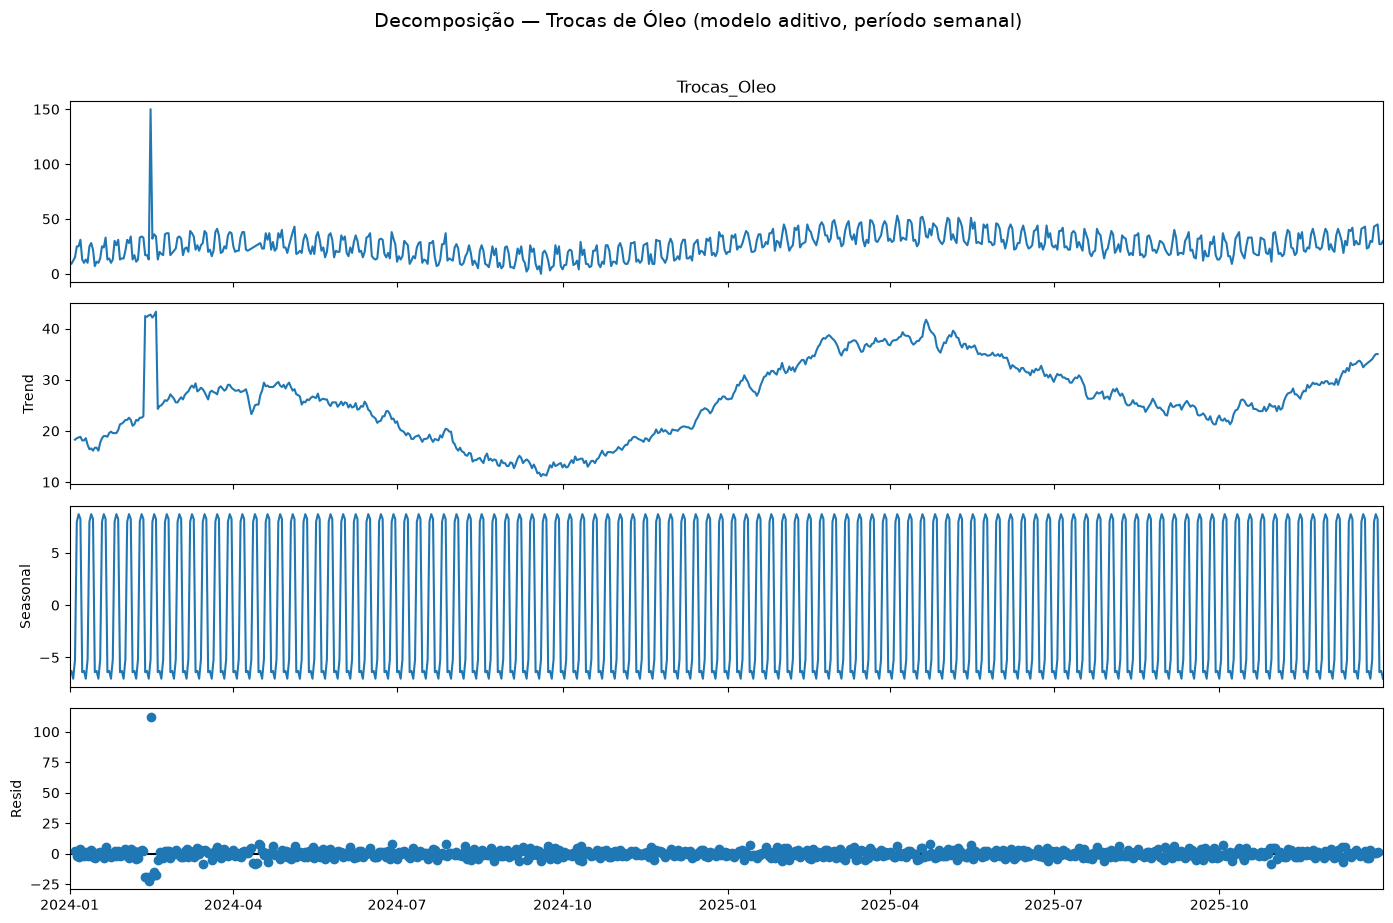

In [6]:
fig = decomposicao_oleo.plot()
fig.set_size_inches(14, 9)
fig.suptitle('Decomposição — Trocas de Óleo (modelo aditivo, período semanal)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

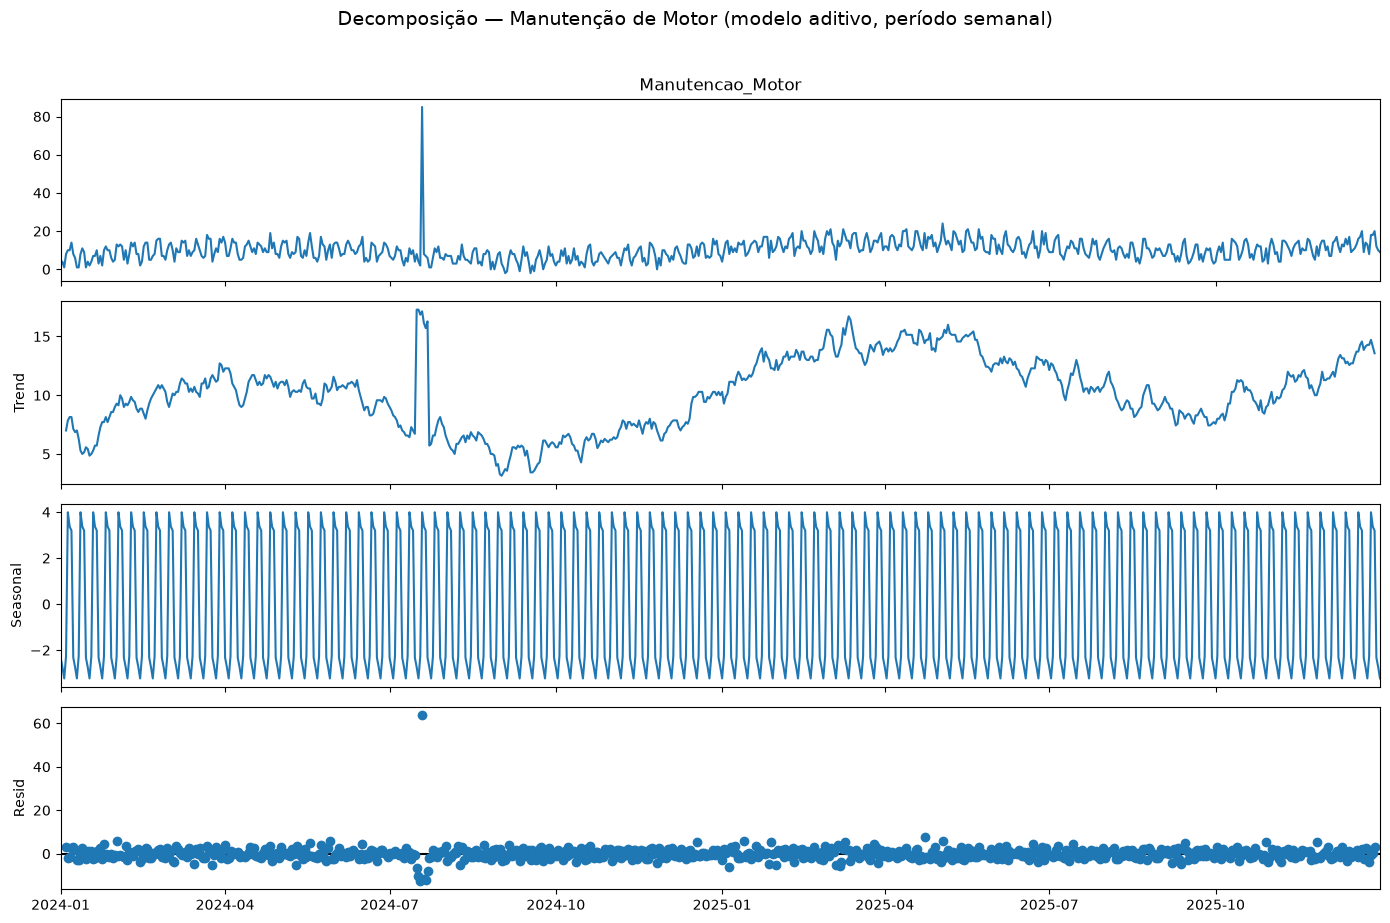

In [7]:
fig = decomposicao_motor.plot()
fig.set_size_inches(14, 9)
fig.suptitle('Decomposição — Manutenção de Motor (modelo aditivo, período semanal)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()